# GBIF earthworm dataset overview

This notebook describes the usable GBIF earthworm image collection: taxonomic coverage, long-tail class balance, occurrence structure, geography/time where available, and representative images. It prefers the curated manifest, then the downloaded manifest, then the raw media manifest. If accepted curated/downloaded rows exist, the overview uses those rows. Species distributions use the same canonical binomial/genus-matching rule as the full-taxonomy training pipeline.

Species names are GBIF occurrence metadata, not independently verified image identifications. The deterministic mosaic is descriptive—not cherry-picked and not model output. Re-run the notebook after the dataset changes.

In [1]:
from pathlib import Path
import hashlib
import json
import math
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import yaml

CONFIG_VALUE = Path('configs/gbif_oligochaeta.yaml')
config_candidates = [CONFIG_VALUE, Path.cwd() / CONFIG_VALUE, Path.cwd().parent / CONFIG_VALUE]
CONFIG_PATH = next((path.resolve() for path in config_candidates if path.is_file()), None)
if CONFIG_PATH is None:
    raise FileNotFoundError(f'Could not resolve GBIF config from: {config_candidates}')
PROJECT_ROOT = CONFIG_PATH.parent.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from worm_species.gbif.full_taxonomy import canonical_taxonomy
with CONFIG_PATH.open() as handle:
    config = yaml.safe_load(handle)

def expand(value):
    if isinstance(value, dict):
        return {key: expand(item) for key, item in value.items()}
    if isinstance(value, list):
        return [expand(item) for item in value]
    if isinstance(value, str):
        return os.path.expandvars(os.path.expanduser(value))
    return value

config = expand(config)
workspace = {key: PROJECT_ROOT / value for key, value in config['workspace'].items()}
full_config_path = PROJECT_ROOT / 'configs' / 'gbif_full_taxonomy.yaml'
full_manifest = None
if full_config_path.is_file():
    full_config = expand(yaml.safe_load(full_config_path.read_text()))
    full_manifest = Path(full_config['paths']['gbif_manifest'])
explicit_manifest = os.environ.get('GBIF_DATASET_MANIFEST')
candidates = [
    Path(explicit_manifest) if explicit_manifest else None,
    full_manifest,
    workspace['curated_manifest'],
    workspace['downloaded_manifest'],
    workspace['manifest'],
]
candidates = [
    path if path.is_absolute() else PROJECT_ROOT / path
    for path in candidates if path is not None
]
MANIFEST_PATH = next((path for path in candidates if path.is_file()), None)
if MANIFEST_PATH is None:
    raise FileNotFoundError(f'No GBIF manifest exists: {candidates}')

OUTPUT_ROOT = Path(os.environ.get(
    'GBIF_DATASET_OVERVIEW_OUTPUT', PROJECT_ROOT / 'outputs' / 'gbif_dataset_overview'
))
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(MANIFEST_PATH, low_memory=False)

# Describe the usable curated/downloaded dataset without changing the source manifest.
dataset = df.copy()
applied_filters = []
if 'download_status' in dataset and dataset['download_status'].eq('downloaded').any():
    dataset = dataset.loc[dataset['download_status'].eq('downloaded')].copy()
    applied_filters.append('download_status == downloaded')
if 'curation_label' in dataset and dataset['curation_label'].eq('keep').any():
    dataset = dataset.loc[dataset['curation_label'].eq('keep')].copy()
    applied_filters.append('curation_label == keep')
if dataset.empty:
    raise ValueError('No usable rows remain after the dataset-view filters')

SPECIES_COLUMN = 'species_label' if 'species_label' in dataset else 'species'
GENUS_COLUMN = 'genus'
OCCURRENCE_COLUMN = 'gbif_id' if 'gbif_id' in dataset else 'occurrence_id'
IMAGE_COLUMN = next(
    (column for column in ('local_path', 'image_path', 'path') if column in dataset), None
)
if SPECIES_COLUMN not in dataset or GENUS_COLUMN not in dataset:
    raise ValueError('The GBIF manifest must contain genus and species labels')

dataset['_raw_species'] = dataset[SPECIES_COLUMN].fillna('').astype(str).str.strip()
canonical = dataset.apply(
    lambda row: canonical_taxonomy(row[GENUS_COLUMN], row[SPECIES_COLUMN]),
    axis=1, result_type='expand',
)
canonical.columns = ['_genus', '_species', '_taxonomy_status']
dataset[['_genus', '_species', '_taxonomy_status']] = canonical
dataset['_species_display'] = dataset['_species'].str.replace('_', ' ', regex=False)
print('Manifest:', MANIFEST_PATH)
print('Rows in source manifest:', f'{len(df):,}')
print('Rows in dataset view:', f'{len(dataset):,}')
print('Filters:', ', '.join(applied_filters) if applied_filters else 'none')
print('Outputs:', OUTPUT_ROOT)


Manifest: /home/devd/worm-species/gbif_oligochaeta/curation/curated_manifest.csv
Rows in source manifest: 29,948
Rows in dataset view: 29,866
Filters: download_status == downloaded, curation_label == keep
Outputs: /home/devd/worm-species/outputs/gbif_dataset_overview


## Dataset at a glance

In [2]:
labelled_species = dataset.loc[dataset['_species'].ne('')]
species_counts = labelled_species.groupby('_species', sort=True).agg(
    images=('_species', 'size'),
    occurrences=(OCCURRENCE_COLUMN, 'nunique'),
).sort_values(['images', '_species'], ascending=[False, True])
species_counts['rank'] = np.arange(1, len(species_counts) + 1)
species_counts['image_share'] = species_counts['images'] / species_counts['images'].sum()
species_counts['cumulative_image_share'] = species_counts['image_share'].cumsum()
species_counts.index.name = 'species'

genus_counts = dataset.loc[dataset['_genus'].ne('')].groupby('_genus', sort=True).agg(
    images=('_genus', 'size'),
    occurrences=(OCCURRENCE_COLUMN, 'nunique'),
    species=('_species', lambda values: values.loc[values.ne('')].nunique()),
).sort_values(['images', '_genus'], ascending=[False, True])
genus_counts.index.name = 'genus'

singletons = int(species_counts['images'].eq(1).sum())
top_ten_share = float(species_counts.head(10)['image_share'].sum()) if len(species_counts) else np.nan
dataset_facts = {
    'images': int(len(dataset)),
    'occurrences': int(dataset[OCCURRENCE_COLUMN].nunique()),
    'genera': int(dataset.loc[dataset['_genus'].ne(''), '_genus'].nunique()),
    'raw_species_labels': int(dataset.loc[dataset['_raw_species'].ne(''), '_raw_species'].nunique()),
    'species': int(len(species_counts)),
    'raw_species_labelled_images': int(dataset['_raw_species'].ne('').sum()),
    'species_labelled_images': int(dataset['_species'].ne('').sum()),
    'species_label_coverage': float(dataset['_species'].ne('').mean()),
    'median_images_per_species': float(species_counts['images'].median()),
    'species_with_one_image': singletons,
    'top_10_species_image_share': top_ten_share,
}
display(pd.Series(dataset_facts, name='value').to_frame())
species_counts.to_csv(OUTPUT_ROOT / 'species_distribution.csv')
genus_counts.to_csv(OUTPUT_ROOT / 'genus_distribution.csv')
dataset['_taxonomy_status'].value_counts().rename('images').to_csv(
    OUTPUT_ROOT / 'taxonomy_status_distribution.csv'
)
(OUTPUT_ROOT / 'dataset_facts.json').write_text(json.dumps(dataset_facts, indent=2) + '\n')


,value
images,29866.000000
occurrences,10330.000000
genera,73.000000
raw_species_labels,166.000000
species,163.000000
raw_species_labelled_images,28958.000000
species_labelled_images,28952.000000
species_label_coverage,0.969397
median_images_per_species,9.000000
species_with_one_image,24.000000


353

## Species abundance and long-tail imbalance

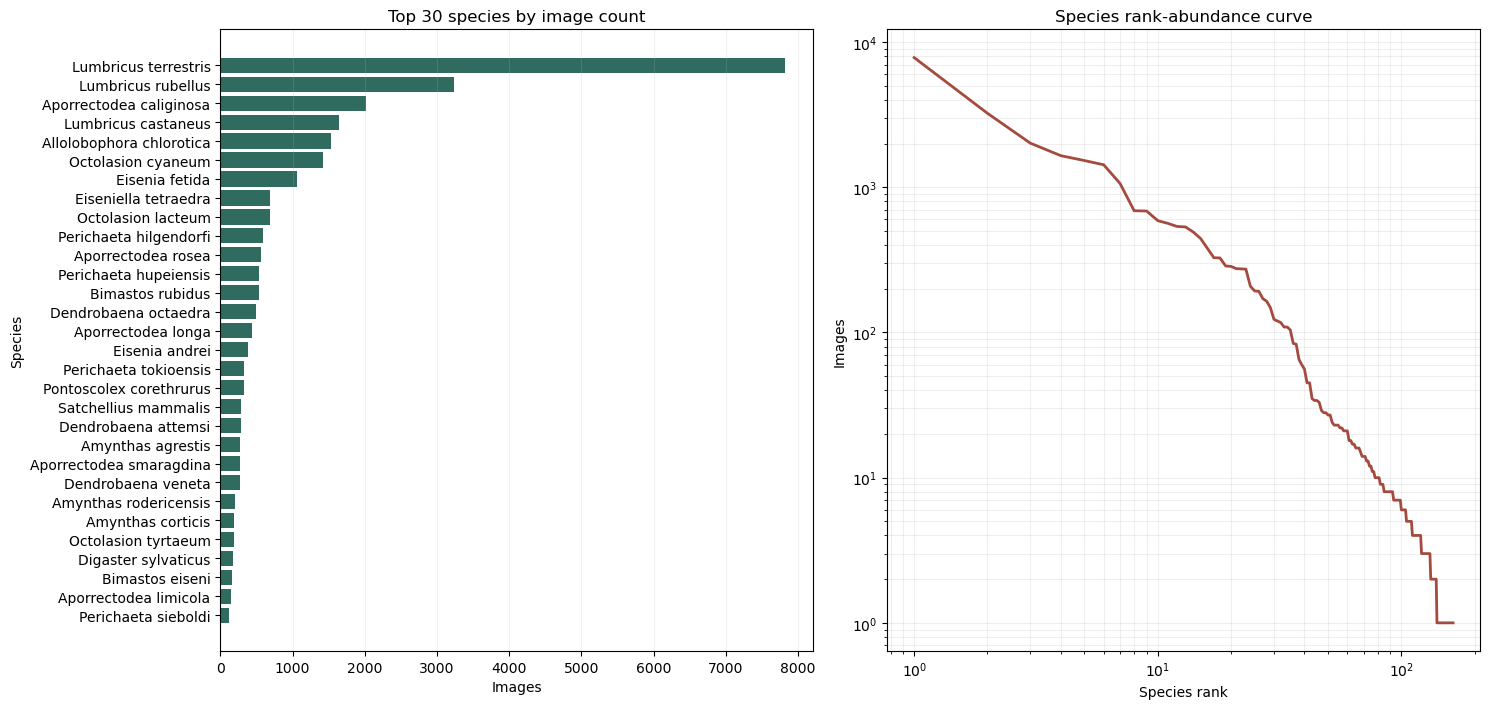

,species
images_per_species,
1,24
2,8
3–5,27
6–10,27
11–25,26
>25,51


In [3]:
top_n = min(30, len(species_counts))
top_species = species_counts.head(top_n).sort_values('images')
fig, axes = plt.subplots(1, 2, figsize=(15, max(6, top_n * 0.24)))
axes[0].barh(
    [label.replace('_', ' ') for label in top_species.index],
    top_species['images'], color='#2F6B5F'
)
axes[0].set(title=f'Top {top_n} species by image count', xlabel='Images', ylabel='Species')
axes[0].grid(axis='x', alpha=.2)
axes[1].plot(species_counts['rank'], species_counts['images'], color='#A44A3F', linewidth=2)
axes[1].set(
    title='Species rank-abundance curve', xlabel='Species rank', ylabel='Images',
    xscale='log', yscale='log'
)
axes[1].grid(alpha=.2, which='both')
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / 'species_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

frequency_bands = pd.cut(
    species_counts['images'], bins=[0, 1, 2, 5, 10, 25, np.inf],
    labels=['1', '2', '3–5', '6–10', '11–25', '>25']
).value_counts(sort=False).rename('species').to_frame()
frequency_bands.index.name = 'images_per_species'
display(frequency_bands)
frequency_bands.to_csv(OUTPUT_ROOT / 'species_frequency_bands.csv')


## Genus composition

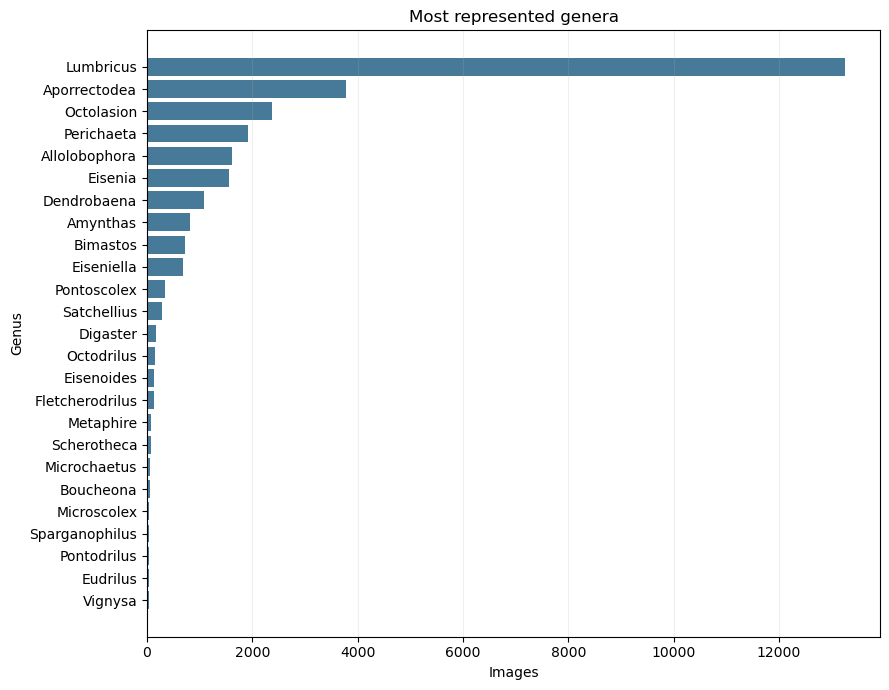

,images,occurrences,species
genus,,,
Lumbricus,13257,5041,7
Aporrectodea,3777,970,11
Octolasion,2370,632,3
Perichaeta,1925,700,13
Allolobophora,1616,628,7
Eisenia,1558,652,4
Dendrobaena,1081,328,8
Amynthas,820,200,8
Bimastos,718,157,3


In [4]:
top_genera = genus_counts.head(min(25, len(genus_counts))).sort_values('images')
fig, ax = plt.subplots(figsize=(9, max(4, len(top_genera) * .28)))
ax.barh(top_genera.index, top_genera['images'], color='#477998')
ax.set(title='Most represented genera', xlabel='Images', ylabel='Genus')
ax.grid(axis='x', alpha=.2)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / 'genus_distribution.png', dpi=180, bbox_inches='tight')
plt.show()
display(genus_counts.head(25))


## Images per occurrence and optional split composition

,images
count,10330.000000
mean,2.891191
std,2.607467
min,1.000000
50%,2.000000
75%,4.000000
90%,6.000000
95%,8.000000
99%,13.000000
max,31.000000


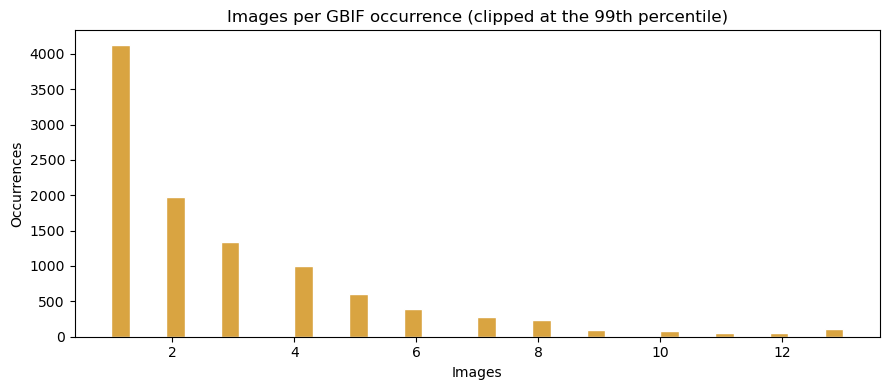

No split column is present in this manifest; showing the unsplit collection.


In [5]:
images_per_occurrence = dataset.groupby(OCCURRENCE_COLUMN).size().rename('images')
display(images_per_occurrence.describe(percentiles=[.5, .75, .9, .95, .99]).to_frame())
upper = max(1, images_per_occurrence.quantile(.99))
fig, ax = plt.subplots(figsize=(9, 4))
images_per_occurrence.clip(upper=upper).plot.hist(
    bins=40, ax=ax, color='#D9A441', edgecolor='white'
)
ax.set(
    title='Images per GBIF occurrence (clipped at the 99th percentile)',
    xlabel='Images', ylabel='Occurrences'
)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / 'images_per_occurrence.png', dpi=180, bbox_inches='tight')
plt.show()

if 'split' in dataset:
    split_composition = pd.crosstab(dataset['_species'], dataset['split'])
    display(dataset['split'].value_counts().to_frame('images'))
    split_composition.to_csv(OUTPUT_ROOT / 'species_by_split.csv')
else:
    print('No split column is present in this manifest; showing the unsplit collection.')


## Geographic and temporal coverage

,occurrences
country,
<missing>,10330


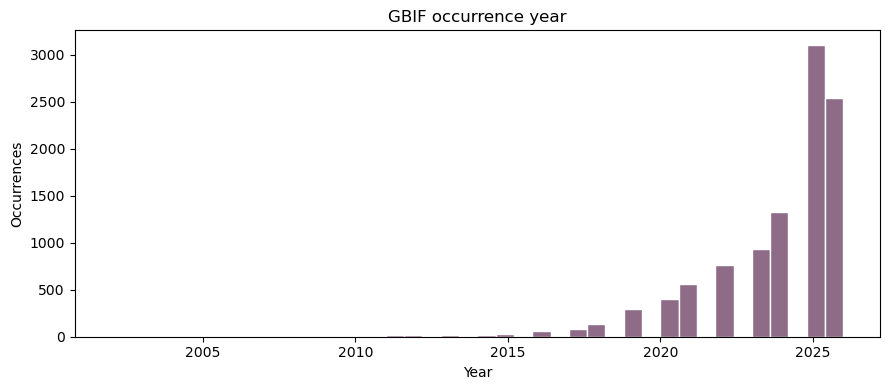

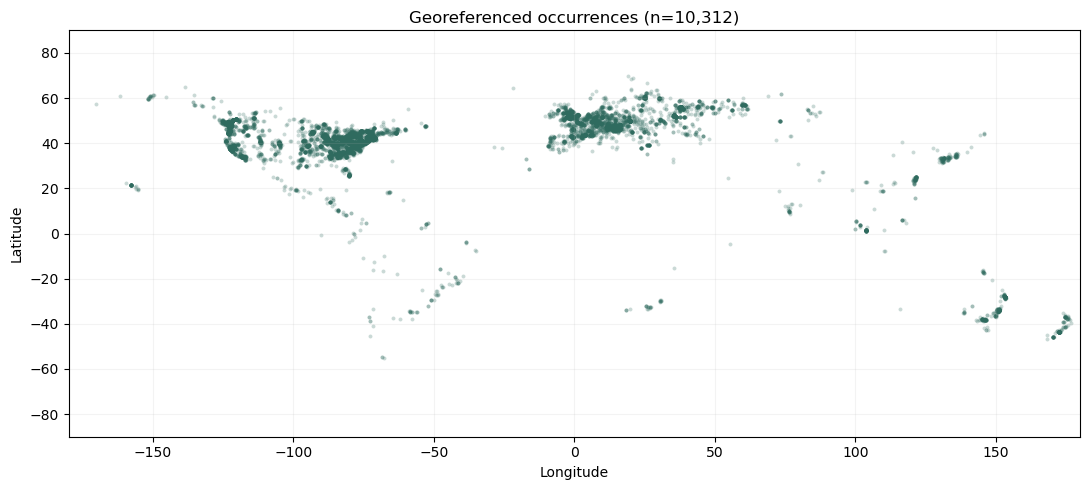

In [6]:
if 'country' in dataset:
    country_counts = dataset.drop_duplicates(OCCURRENCE_COLUMN)['country'].fillna('<missing>').value_counts()
    display(country_counts.head(25).to_frame('occurrences'))
    country_counts.to_csv(OUTPUT_ROOT / 'country_distribution.csv')
else:
    print('Country metadata is not present.')

if 'year' in dataset:
    years = pd.to_numeric(
        dataset.drop_duplicates(OCCURRENCE_COLUMN)['year'], errors='coerce'
    ).dropna()
    years = years[(years >= 1700) & (years <= pd.Timestamp.now().year)]
    if len(years):
        fig, ax = plt.subplots(figsize=(9, 4))
        years.plot.hist(bins=40, ax=ax, color='#8E6C88', edgecolor='white')
        ax.set(title='GBIF occurrence year', xlabel='Year', ylabel='Occurrences')
        fig.tight_layout()
        fig.savefig(OUTPUT_ROOT / 'occurrence_year.png', dpi=180, bbox_inches='tight')
        plt.show()
else:
    print('Year metadata is not present.')

if {'decimal_latitude', 'decimal_longitude'} <= set(dataset):
    coordinates = dataset.drop_duplicates(OCCURRENCE_COLUMN).copy()
    coordinates['decimal_latitude'] = pd.to_numeric(coordinates['decimal_latitude'], errors='coerce')
    coordinates['decimal_longitude'] = pd.to_numeric(coordinates['decimal_longitude'], errors='coerce')
    coordinates = coordinates.dropna(subset=['decimal_latitude', 'decimal_longitude'])
    if len(coordinates):
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.scatter(
            coordinates['decimal_longitude'], coordinates['decimal_latitude'],
            s=8, alpha=.25, color='#2F6B5F', linewidths=0
        )
        ax.set(
            title=f'Georeferenced occurrences (n={len(coordinates):,})',
            xlabel='Longitude', ylabel='Latitude', xlim=(-180, 180), ylim=(-90, 90)
        )
        ax.grid(alpha=.15)
        fig.tight_layout()
        fig.savefig(OUTPUT_ROOT / 'geographic_coverage.png', dpi=180, bbox_inches='tight')
        plt.show()
else:
    print('Coordinate metadata is not present.')


## Frequency-stratified sample mosaic

Species are selected at evenly spaced positions along the abundance ranking, so the mosaic includes common, middle-frequency, and rare taxa. Within each species, the image is selected deterministically from its identifiers and path.

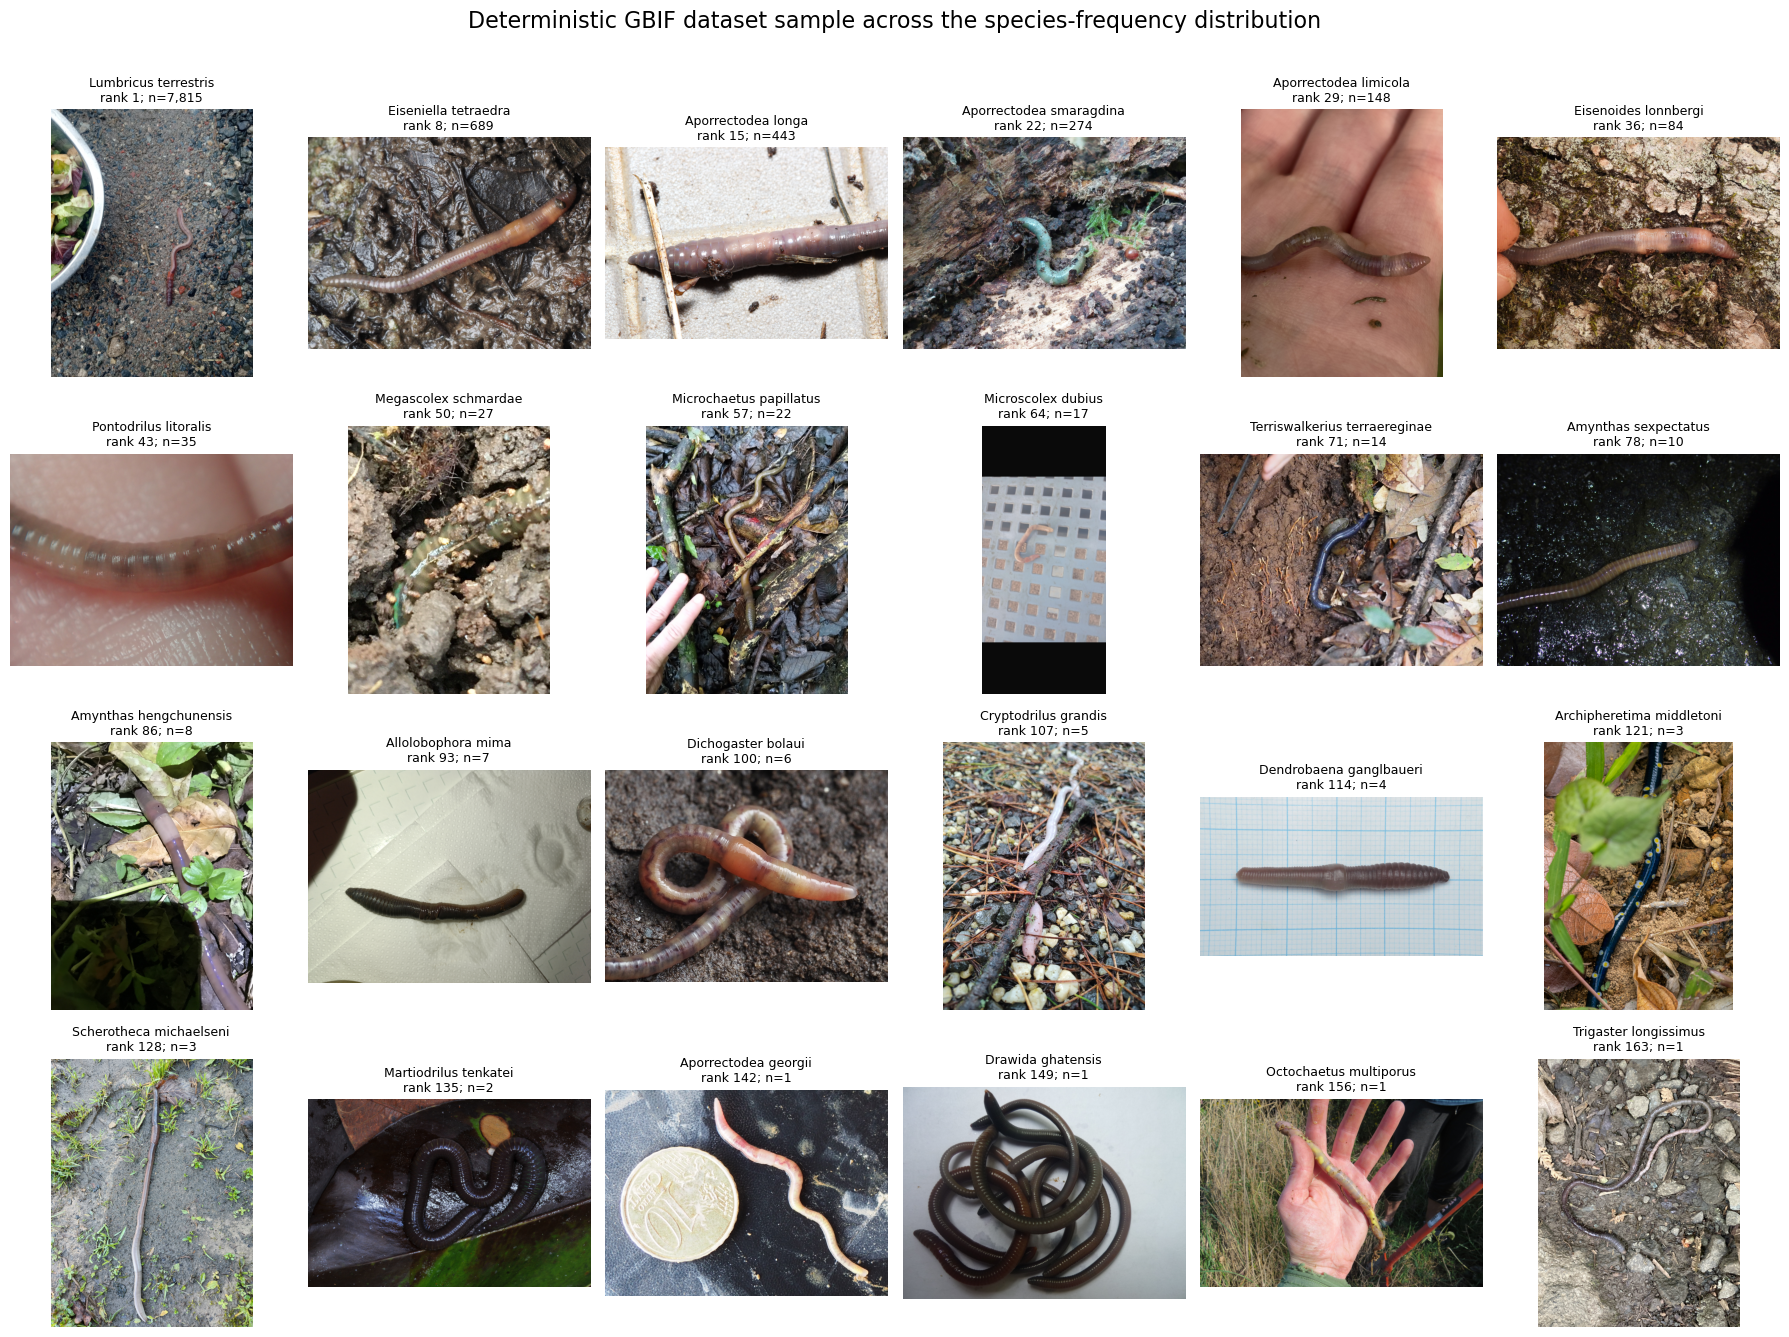

,species,species_rank,species_images,image_id,gbif_id,image_path
0,Lumbricus_terrestris,1,7815,0f9a8168ebba72a9136e8aae,6130997292,/home/devd/worm-species/gbif_oligochaeta/image...
1,Eiseniella_tetraedra,8,689,638bbab666e453fa3251d4a2,5827959375,/home/devd/worm-species/gbif_oligochaeta/image...
2,Aporrectodea_longa,15,443,8b669af125a241f452187be8,5892893739,/home/devd/worm-species/gbif_oligochaeta/image...
3,Aporrectodea_smaragdina,22,274,0222d559c4e2c6c6de929cab,4599771072,/home/devd/worm-species/gbif_oligochaeta/image...
4,Aporrectodea_limicola,29,148,f0834901ff7413220ec2a6c9,6253180025,/home/devd/worm-species/gbif_oligochaeta/image...
5,Eisenoides_lonnbergi,36,84,b78ae31cbc3d101e1ee288e1,6274344760,/home/devd/worm-species/gbif_oligochaeta/image...
6,Pontodrilus_litoralis,43,35,baa3f8dc564ebdd449d2255a,5007999537,/home/devd/worm-species/gbif_oligochaeta/image...
7,Megascolex_schmardae,50,27,3a515bd12560f83ba7fb388d,5062527462,/home/devd/worm-species/gbif_oligochaeta/image...
8,Microchaetus_papillatus,57,22,a613ffa2f46699c76b9ee273,5281825212,/home/devd/worm-species/gbif_oligochaeta/image...
9,Microscolex_dubius,64,17,eb069b945925bdc24a103805,5087638489,/home/devd/worm-species/gbif_oligochaeta/image...


In [7]:
if IMAGE_COLUMN is None:
    raise ValueError('No local image-path column is available for the mosaic')

def resolve_image_path(value):
    raw = Path(str(value))
    candidates = [raw] if raw.is_absolute() else [MANIFEST_PATH.parent / raw, PROJECT_ROOT / raw]
    return next((path.resolve() for path in candidates if path.is_file()), candidates[0])

dataset['_resolved_image_path'] = dataset[IMAGE_COLUMN].map(resolve_image_path)
available = dataset.loc[
    dataset['_species'].ne('') & dataset['_resolved_image_path'].map(Path.is_file)
].copy()
MOSAIC_SPECIES = 24
MOSAIC_COLUMNS = 6
ranked_species = species_counts.index.tolist()
if not ranked_species or available.empty:
    raise ValueError('No labelled local images are available for the sample mosaic')
rank_positions = np.unique(np.rint(np.linspace(
    0, len(ranked_species) - 1, min(MOSAIC_SPECIES, len(ranked_species))
)).astype(int))
selected_species = [ranked_species[position] for position in rank_positions]
rank_lookup = species_counts['rank'].astype(int).to_dict()

mosaic_rows = []
for species in selected_species:
    candidates = available.loc[available['_species'].eq(species)].copy()
    if candidates.empty:
        continue
    candidates['_selection_key'] = candidates.apply(
        lambda row: hashlib.sha256(
            f"{species}|{row.get('image_id', '')}|{row[OCCURRENCE_COLUMN]}|{row['_resolved_image_path']}".encode()
        ).hexdigest(), axis=1,
    )
    selected = candidates.sort_values('_selection_key').iloc[0]
    mosaic_rows.append({
        'species': species,
        'species_rank': rank_lookup[species],
        'species_images': int(species_counts.loc[species, 'images']),
        'image_id': selected.get('image_id', ''),
        'gbif_id': selected.get(OCCURRENCE_COLUMN, ''),
        'image_path': str(selected['_resolved_image_path']),
    })
mosaic_samples = pd.DataFrame(mosaic_rows).sort_values('species_rank')
mosaic_samples.to_csv(OUTPUT_ROOT / 'sample_mosaic_manifest.csv', index=False)

rows = math.ceil(len(mosaic_samples) / MOSAIC_COLUMNS)
fig, axes = plt.subplots(rows, MOSAIC_COLUMNS, figsize=(18, 3.4 * rows), squeeze=False)
for ax, sample in zip(axes.flat, mosaic_samples.itertuples(index=False)):
    try:
        with Image.open(sample.image_path) as source:
            image = ImageOps.exif_transpose(source).convert('RGB')
        ax.imshow(image)
    except Exception as exc:
        ax.text(.5, .5, f'Image error\n{type(exc).__name__}', ha='center', va='center')
    ax.set_title(
        f"{sample.species.replace('_', ' ')}\n"
        f"rank {sample.species_rank}; n={sample.species_images:,}",
        fontsize=9,
    )
    ax.axis('off')
for ax in axes.flat[len(mosaic_samples):]:
    ax.axis('off')
fig.suptitle('Deterministic GBIF dataset sample across the species-frequency distribution', fontsize=16)
fig.tight_layout(rect=(0, 0, 1, .97))
fig.savefig(OUTPUT_ROOT / 'sample_mosaic.png', dpi=180, bbox_inches='tight')
plt.show()
display(mosaic_samples)


## Generated overview artifacts

In [8]:
generated = sorted(path.name for path in OUTPUT_ROOT.iterdir() if path.is_file())
display(pd.DataFrame({'artifact': generated}))
print('All outputs:', OUTPUT_ROOT)


,artifact
0,country_distribution.csv
1,dataset_facts.json
2,genus_distribution.csv
3,genus_distribution.png
4,geographic_coverage.png
5,images_per_occurrence.png
6,occurrence_year.png
7,sample_mosaic.png
8,sample_mosaic_manifest.csv
9,species_distribution.csv


All outputs: /home/devd/worm-species/outputs/gbif_dataset_overview
